# Notebook 04 — 建模与评估

**输入**：`data/processed/03_modeling_dataset.csv`（276 行 × 35 列）  
**输出**：`models/best_model.pkl`（最优模型文件）

## 流程
| Step | 内容 |
|------|------|
| 1 | 加载数据，定义特征和标签 |
| 2 | 缺失值填充 + 时间划分训练/测试集 |
| 3 | 训练三个模型：逻辑回归 / 随机森林 / XGBoost |
| 4 | 对比评估（AUC、F1、Precision、Recall） |
| 5 | 保存最优模型 |

## 为什么按时间划分训练/测试集？
我们有 2021、2022、2023 三年的数据。  
用 **2021+2022 年训练，2023 年测试**，模拟真实场景：用历史数据训练，预测未来是否 ST。  
这比随机划分更严格，也更符合实际投资逻辑。

In [13]:
# 安装建模所需的库（第一次运行时执行）
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "scikit-learn", "xgboost", "matplotlib", "seaborn", "joblib", "-q"])


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['/usr/local/bin/python3', '-m', 'pip', 'install', 'scikit-learn', 'xgboost', 'matplotlib', 'seaborn', 'joblib', '-q'], returncode=0)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import (roc_auc_score, f1_score,
                                     precision_score, recall_score,
                                     accuracy_score, roc_curve,
                                     ConfusionMatrixDisplay)
from xgboost import XGBClassifier

# 设置中文字体（Mac 用黑体）
plt.rcParams["font.family"] = "Arial Unicode MS"
plt.rcParams["axes.unicode_minus"] = False

PROCESSED_DIR = Path("..").resolve() / "data" / "processed"
MODELS_DIR    = Path("..").resolve() / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("✓ 依赖导入完成")

✓ 依赖导入完成


## Step 1 — 加载数据，定义特征和标签

In [15]:
df = pd.read_csv(PROCESSED_DIR / "03_modeling_dataset.csv", encoding="utf-8-sig")

# 元数据列（不参与建模）
meta_cols = ["stock_code", "stock_name", "sw_industry", "year", "label"]

# 特征列 = 除元数据外的所有列
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"总样本数: {len(df)}（正样本 {(df['label']==1).sum()} / 负样本 {(df['label']==0).sum()}）")
print(f"特征数量: {len(feature_cols)}")
print(f"\n特征列表:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

总样本数: 276（正样本 138 / 负样本 138）
特征数量: 31

特征列表:
   1. ar_turnover
   2. asset_turnover
   3. cash_interest_coverage
   4. current_asset_turnover
   5. current_ratio
   6. debt_to_asset
   7. debt_to_equity
   8. ebit
   9. eps
  10. fixed_asset_turnover
  11. gross_margin
  12. inventory_turnover
  13. net_assets_growth
  14. net_margin
  15. net_profit_growth
  16. ocf_per_share
  17. operating_cash_flow
  18. operating_income_ratio
  19. operating_margin
  20. quick_ratio
  21. retained_earnings
  22. revenue_growth
  23. roa
  24. roe
  25. top10_holders_pct
  26. total_assets
  27. total_assets_growth
  28. total_revenue
  29. working_capital
  30. audit_opinion_code
  31. is_non_standard_audit


## Step 2 — 缺失值填充 + 按时间划分训练/测试集

**缺失值处理**：用每列的**中位数**填充。中位数对异常值不敏感，适合财务数据。  
**划分方式**：2021+2022 年 → 训练集；2023 年 → 测试集。

In [16]:
# ── 按时间划分 ────────────────────────────────────────────────────
train_df = df[df["year"] <= 2022].copy()   # 2021 + 2022 年做训练
test_df  = df[df["year"] == 2023].copy()   # 2023 年做测试

X_train_raw = train_df[feature_cols]
y_train     = train_df["label"]
X_test_raw  = test_df[feature_cols]
y_test      = test_df["label"]

print(f"训练集: {len(train_df)} 行（2021+2022年）")
print(f"  正样本: {y_train.sum()}，负样本: {(y_train==0).sum()}")
print(f"\n测试集: {len(test_df)} 行（2023年）")
print(f"  正样本: {y_test.sum()}，负样本: {(y_test==0).sum()}")

# ── 缺失值填充（用训练集的中位数，同样应用到测试集）────────────────
# 注意：必须先 fit 训练集，再 transform 测试集，不能用测试集的数据
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_raw)   # 学习中位数 + 填充
X_test_imputed  = imputer.transform(X_test_raw)         # 只填充，不重新学习

# ── 特征标准化（逻辑回归需要，树模型不强制但统一处理）───────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imputed)
X_test  = scaler.transform(X_test_imputed)

print(f"\n✓ 缺失值填充完成，特征标准化完成")

训练集: 134 行（2021+2022年）
  正样本: 67，负样本: 67

测试集: 142 行（2023年）
  正样本: 71，负样本: 71

✓ 缺失值填充完成，特征标准化完成


## Step 3 — 训练三个模型

训练三个模型做对比：
- **逻辑回归**：线性模型，基准线，可解释性强
- **随机森林**：集成树模型，对异常值鲁棒
- **XGBoost**：梯度提升树，通常效果最好，也是后续 SHAP 分析的主角

In [17]:
# ── 定义三个模型 ─────────────────────────────────────────────────
models = {
    "逻辑回归": LogisticRegression(
        max_iter=1000,       # 最大迭代次数，避免不收敛警告
        random_state=42,
        class_weight="balanced"  # 自动处理样本不平衡
    ),
    "随机森林": RandomForestClassifier(
        n_estimators=200,    # 200 棵树
        max_depth=6,         # 限制深度，防止过拟合
        random_state=42,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,  # 学习率小一点，更稳定
        subsample=0.8,       # 每棵树只用 80% 的样本，防止过拟合
        random_state=42,
        eval_metric="logloss",
        verbosity=0          # 不打印训练日志
    ),
}

# ── 逐个训练 ─────────────────────────────────────────────────────
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✓ {name} 训练完成")

✓ 逻辑回归 训练完成
✓ 随机森林 训练完成
✓ XGBoost 训练完成


## Step 4 — 对比评估

计算四个指标，并画 ROC 曲线：
- **AUC**：模型区分正负样本的能力，越接近 1 越好（>0.7 就不错）
- **F1**：精确率和召回率的调和平均，平衡两者
- **Precision（精确率）**：预测为 ST 的公司中，真正是 ST 的比例
- **Recall（召回率）**：真正 ST 的公司中，被模型找到的比例

In [18]:
# ── 计算各模型指标 ────────────────────────────────────────────────
results = []
for name, model in trained_models.items():
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]   # 正样本概率

    results.append({
        "模型":      name,
        "AUC":       round(roc_auc_score(y_test, y_prob), 4),
        "F1":        round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).set_index("模型")
print("=" * 55)
print("              模型对比结果（测试集 2023年）")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)

              模型对比结果（测试集 2023年）
            AUC      F1  Precision  Recall  Accuracy
模型                                                  
逻辑回归     0.7014  0.6486     0.6234  0.6761    0.6338
随机森林     0.7907  0.7470     0.6526  0.8732    0.7042
XGBoost  0.7415  0.6842     0.6420  0.7324    0.6620


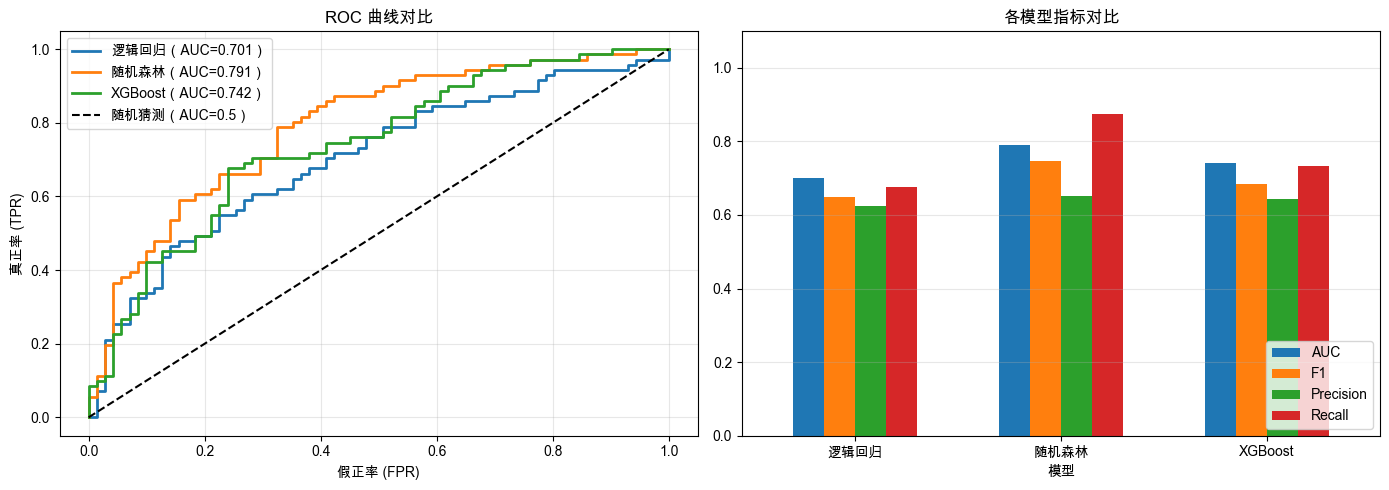

✓ 图表已保存到 models/model_comparison.png


In [19]:
# ── 画 ROC 曲线（三个模型放在同一张图里对比）────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：ROC 曲线
ax = axes[0]
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name}（AUC={auc_score:.3f}）", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", label="随机猜测（AUC=0.5）")
ax.set_xlabel("假正率 (FPR)")
ax.set_ylabel("真正率 (TPR)")
ax.set_title("ROC 曲线对比")
ax.legend()
ax.grid(alpha=0.3)

# 右图：指标条形图
ax2 = axes[1]
results_df[["AUC", "F1", "Precision", "Recall"]].plot(
    kind="bar", ax=ax2, rot=0, width=0.6
)
ax2.set_title("各模型指标对比")
ax2.set_ylim(0, 1.1)
ax2.legend(loc="lower right")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 图表已保存到 models/model_comparison.png")

## Step 5 — 保存最优模型

选 AUC 最高的模型保存，同时保存 `imputer` 和 `scaler`——部署 Streamlit Demo 时需要用同样的预处理步骤。

In [20]:
# AUC 最高的模型就是最优模型
best_name = results_df["AUC"].idxmax()
best_model = trained_models[best_name]
best_auc   = results_df.loc[best_name, "AUC"]

print(f"最优模型: {best_name}（AUC={best_auc}）")

# 保存模型 + 预处理器（三个文件打包成一个 dict，方便加载）
model_bundle = {
    "model":        best_model,
    "imputer":      imputer,
    "scaler":       scaler,
    "feature_cols": feature_cols,
    "model_name":   best_name,
}
joblib.dump(model_bundle, MODELS_DIR / "best_model.pkl")
print(f"✓ 已保存: models/best_model.pkl")

# 同时保存完整的评估结果
results_df.to_csv(MODELS_DIR / "model_results.csv", encoding="utf-8-sig")
print(f"✓ 已保存: models/model_results.csv")

print("\n=== 最终评估结果 ===")
print(results_df.to_string())

最优模型: 随机森林（AUC=0.7907）
✓ 已保存: models/best_model.pkl
✓ 已保存: models/model_results.csv

=== 最终评估结果 ===
            AUC      F1  Precision  Recall  Accuracy
模型                                                  
逻辑回归     0.7014  0.6486     0.6234  0.6761    0.6338
随机森林     0.7907  0.7470     0.6526  0.8732    0.7042
XGBoost  0.7415  0.6842     0.6420  0.7324    0.6620


## Step 6 — XGBoost 调参（RandomizedSearchCV）

**为什么用 RandomizedSearchCV 而不是 GridSearch？**  
GridSearch 会穷举所有参数组合，太慢。RandomizedSearch 随机抽取指定数量的组合，速度快 10 倍，效果接近。  
用 **5折交叉验证 + AUC 评分** 选出最优参数，再在测试集上验证。

In [21]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# ── 参数搜索空间 ──────────────────────────────────────────────────
param_grid = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [3, 4, 5, 6],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],  # 每棵树随机使用的特征比例
    "min_child_weight": [1, 3, 5],                    # 叶节点最小样本权重，防过拟合
    "gamma":            [0, 0.1, 0.2, 0.3],           # 分裂所需最小损失减少量
}

# ── 5 折交叉验证策略 ──────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 随机搜索（抽取 50 个参数组合，每个跑 5 折，共 250 次训练）────
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,           # 随机抽 50 组参数
    scoring="roc_auc",   # 以 AUC 为优化目标
    cv=cv,
    random_state=42,
    n_jobs=-1,           # 用所有 CPU 核心并行，加快速度
    verbose=1
)

print("开始调参（预计 1-2 分钟）...")
search.fit(X_train, y_train)

print(f"\n✓ 调参完成")
print(f"最优参数: {search.best_params_}")
print(f"交叉验证最优 AUC: {search.best_score_:.4f}")

开始调参（预计 1-2 分钟）...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✓ 调参完成
最优参数: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
交叉验证最优 AUC: 0.7388


In [22]:
# ── 用最优参数在测试集上评估，和调参前对比 ───────────────────────
best_xgb = search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

tuned_result = {
    "AUC":       round(roc_auc_score(y_test, y_prob_tuned), 4),
    "F1":        round(f1_score(y_test, y_pred_tuned), 4),
    "Precision": round(precision_score(y_test, y_pred_tuned), 4),
    "Recall":    round(recall_score(y_test, y_pred_tuned), 4),
    "Accuracy":  round(accuracy_score(y_test, y_pred_tuned), 4),
}

print("=" * 55)
print("         调参前后 XGBoost 对比")
print("=" * 55)
before = results_df.loc["XGBoost"]
print(f"{'指标':<12} {'调参前':>10} {'调参后':>10} {'变化':>8}")
print("-" * 45)
for metric in ["AUC", "F1", "Precision", "Recall", "Accuracy"]:
    before_val = before[metric]
    after_val  = tuned_result[metric]
    delta      = after_val - before_val
    sign       = "↑" if delta > 0 else ("↓" if delta < 0 else "→")
    print(f"{metric:<12} {before_val:>10.4f} {after_val:>10.4f} {sign}{abs(delta):>6.4f}")
print("=" * 55)

# 和随机森林对比
print(f"\n随机森林 AUC: {results_df.loc['随机森林', 'AUC']:.4f}")
print(f"调参后XGBoost AUC: {tuned_result['AUC']:.4f}")

         调参前后 XGBoost 对比
指标                  调参前        调参后       变化
---------------------------------------------
AUC              0.7415     0.7350 ↓0.0065
F1               0.6842     0.6875 ↑0.0033
Precision        0.6420     0.6180 ↓0.0240
Recall           0.7324     0.7746 ↑0.0422
Accuracy         0.6620     0.6479 ↓0.0141

随机森林 AUC: 0.7907
调参后XGBoost AUC: 0.7350


In [23]:
# ── 更新最优模型（如果调参后 XGBoost 超过随机森林就替换）─────────
xgb_auc = tuned_result["AUC"]
rf_auc  = results_df.loc["随机森林", "AUC"]

if xgb_auc >= rf_auc:
    final_model      = best_xgb
    final_model_name = "XGBoost（调参后）"
    print(f"✓ 调参后 XGBoost（AUC={xgb_auc}）超过随机森林（AUC={rf_auc}），使用 XGBoost")
else:
    final_model      = trained_models["随机森林"]
    final_model_name = "随机森林"
    print(f"随机森林（AUC={rf_auc}）仍优于调参后 XGBoost（AUC={xgb_auc}），保留随机森林")

# 覆盖保存最优模型
model_bundle = {
    "model":        final_model,
    "imputer":      imputer,
    "scaler":       scaler,
    "feature_cols": feature_cols,
    "model_name":   final_model_name,
}
joblib.dump(model_bundle, MODELS_DIR / "best_model.pkl")
print(f"✓ 已更新保存: models/best_model.pkl（{final_model_name}）")

随机森林（AUC=0.7907）仍优于调参后 XGBoost（AUC=0.735），保留随机森林
✓ 已更新保存: models/best_model.pkl（随机森林）


## 本节小结

**这一步完成了：**
- 用 2021+2022 年数据训练，2023 年数据测试（时间序列划分）
- 训练并对比了逻辑回归、随机森林、XGBoost 三个模型
- 保存了最优模型 + 预处理器到 `models/best_model.pkl`

**下一步（Notebook 05）：**
- 对最优模型做 SHAP 分析
- 输出特征重要性图，解释哪些财务指标对 ST 预警贡献最大

**⚠️ 进入 Notebook 05 前，请确认：**
1. Step 4 的对比表格里三个模型都有 AUC 数值
2. `models/best_model.pkl` 文件已生成
3. ROC 曲线图正常显示